# Getting Started: DiffBot Mobile Robot

This notebook walks through the core TAMPanda APIs for the **DiffBot** differential-drive mobile robot:

1. Building a scene with `MobileSceneBuilder`
2. Planning collision-free paths with `AStarNav`
3. Executing paths with `DifferentialDriveController`
4. Reading the **Lidar** sensor
5. Reading the **IMU** (accelerometer + gyroscope)
6. Measuring odometry drift

Everything runs **headless** — no viewer is launched. To see the robot navigating in a window, run `python examples/basic_navigation.py`.

First we do all imports and define helper functions for rendering and visualisation that we reuse throughout.

In [21]:
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import mujoco
from IPython.display import display, Image

from tampanda import (
    MobileSceneBuilder,
    MobileEnvironment,
    DifferentialDriveController,
    AStarNav,
    Lidar,
    RobotSensors,
)
from tampanda.scenes import WALL_TEMPLATE


def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    buf.seek(0)
    display(Image(buf.read()))
    plt.close(fig)


def render_view(env, lookat=(1.5, 0.0, 0.3), distance=5.5,
                azimuth=0.0, elevation=-70.0, width=640, height=360):
    """Render a headless RGB image of the mobile robot scene."""
    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(env.model, cam)
    cam.lookat[:] = lookat
    cam.distance = distance
    cam.azimuth = azimuth
    cam.elevation = elevation
    r = mujoco.Renderer(env.model, height=height, width=width)
    r.update_scene(env.data, camera=cam)
    img = r.render()
    r.close()
    return img


def show_scene(env, title="", lookat=(1.5, 0.0, 0.3)):
    """Show top and side views of the scene side-by-side."""
    top  = render_view(env, lookat=lookat, azimuth=0,  elevation=-70)
    side = render_view(env, lookat=lookat, azimuth=90, elevation=-20)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(top);  axes[0].set_title("top view");  axes[0].axis("off")
    axes[1].imshow(side); axes[1].set_title("side view"); axes[1].axis("off")
    if title:
        plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    show_fig(fig)


def reset_robot(env, x=0.0, y=0.0, theta=0.0):
    """Reset the robot to a given pose and zero all velocities."""
    env.set_pose(x, y, theta)
    env.data.qvel[:] = 0.0
    env.data.ctrl[:] = 0.0
    mujoco.mj_forward(env.model, env.data)


def plot_path(path, start, goal):
    """Plot the A* path overlaid on the slalom obstacle layout."""
    fig, ax = plt.subplots(figsize=(12, 4))
    for cx, cy in [(1.2, -1.0), (1.2, -0.1), (2.4, 0.1), (2.4, 1.0)]:
        ax.add_patch(patches.Rectangle(
            (cx - 0.05, cy - 0.60), 0.10, 1.20,
            linewidth=1, edgecolor='black', facecolor='dimgray', alpha=0.7,
        ))
    xs, ys = zip(*path)
    ax.plot(xs, ys, 'b-o', ms=5, lw=2, label='A* path', zorder=3)
    ax.plot(*start, 'g^', ms=12, label='start', zorder=4)
    ax.plot(*goal,  'r*', ms=14, label='goal',  zorder=4)
    ax.set_xlim(-0.4, 3.8); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.set_title('A* planned path through slalom')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    show_fig(fig)


print("Imports OK")

Imports OK


---
## 1. Building a Mobile Scene

`MobileSceneBuilder` works just like `ArmSceneBuilder` but targets the DiffBot model. You register wall/pillar templates and place instances at desired positions.

Here we build a two-chicane slalom: two walls offset to opposite sides of the corridor, forcing the robot to weave an S-curve.

Initial pose: x=0.00 m, y=0.00 m, θ=0.0°
Simulation timestep: 0.002 s


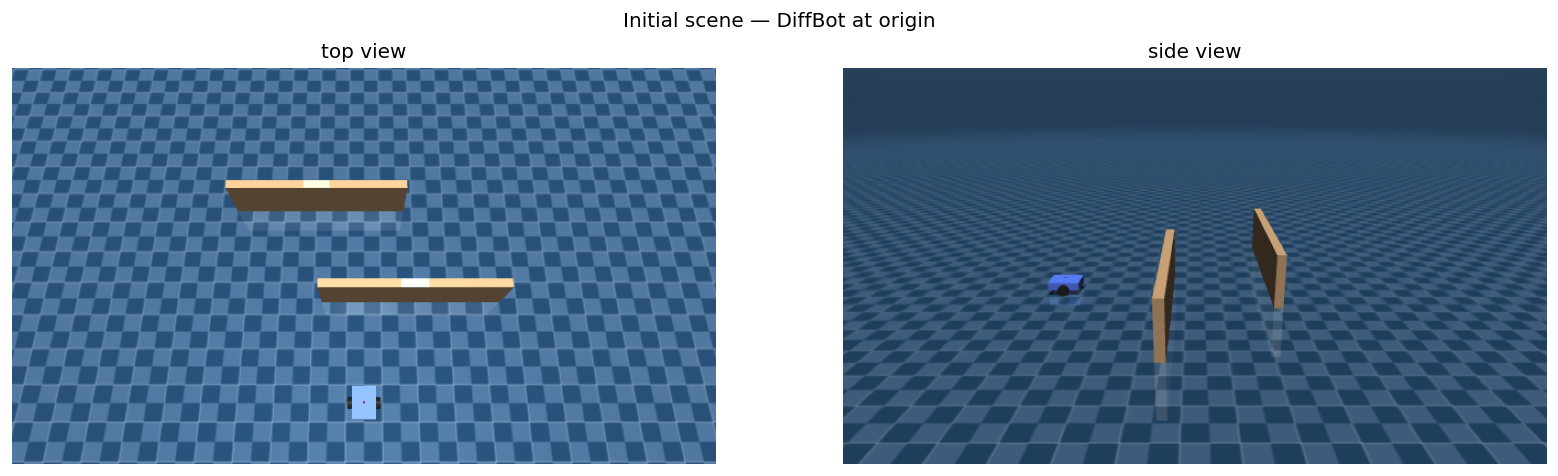

In [22]:
builder = MobileSceneBuilder()
builder.add_resource("wall", WALL_TEMPLATE)

# Chicane A at x=1.2: gap at y > +0.5  (wall covers y=−1.6..+0.5)
builder.add_object("wall", pos=[1.2, -1.0, 0.30], euler=[0, 0, 90], name="wall_a0")
builder.add_object("wall", pos=[1.2, -0.1, 0.30], euler=[0, 0, 90], name="wall_a1")

# Chicane B at x=2.4: gap at y < −0.5  (wall covers y=−0.5..+1.6)
builder.add_object("wall", pos=[2.4,  0.1, 0.30], euler=[0, 0, 90], name="wall_b0")
builder.add_object("wall", pos=[2.4,  1.0, 0.30], euler=[0, 0, 90], name="wall_b1")

# rate=1_000_000 → no real-time sleep between physics steps (fast headless execution)
env = builder.build_env(env_class=MobileEnvironment, rate=1_000_000)
reset_robot(env)

x, y, theta = env.get_pose()
print(f"Initial pose: x={x:.2f} m, y={y:.2f} m, θ={np.degrees(theta):.1f}°")
print(f"Simulation timestep: {env.model.opt.timestep} s")

show_scene(env, title="Initial scene — DiffBot at origin")

---
## 2. A* Navigation Planning

`AStarNav` builds a 2D occupancy grid from the MuJoCo scene geometry — including sphere, capsule, cylinder, box, and mesh geoms — and inflates each obstacle by the robot radius. It then runs A\* on the grid and applies a **string-pulling** post-processor to remove redundant waypoints.

| Parameter | Effect |
|-----------|--------|
| `resolution` | cell size in metres (smaller = finer grid, slower) |
| `robot_radius_buffer` | extra clearance added around obstacles |
| `x_range`, `y_range` | bounding box of the navigable workspace |

In [23]:
planner = AStarNav(
    env,
    x_range=(-0.3, 3.7),
    y_range=(-1.5, 1.5),
    resolution=0.06,
    robot_radius_buffer=0.10,
)

START = (0.0, 0.0)
GOAL  = (3.4, 0.0)

print(f"Planning {START} → {GOAL} ...")
path = planner.plan(START, GOAL)

if path is not None:
    path = planner.smooth_path(path)
    print(f"Path found: {len(path)} waypoints after smoothing")
else:
    print("No path found — check obstacle layout or planner bounds")

[AStarNav] Building 68×51 occupancy grid (3468 cells, resolution=0.06 m, robot_radius=0.318 m) …
[AStarNav] Grid ready — 986/3468 cells occupied.
Planning (0.0, 0.0) → (3.4, 0.0) ...
Path found: 9 waypoints after smoothing


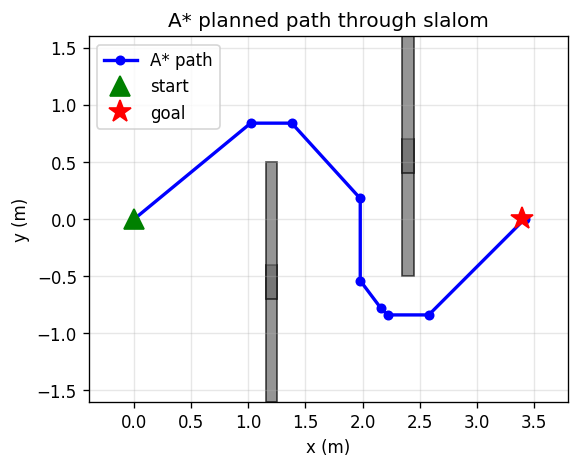

In [24]:
if path is not None:
    plot_path(path, START, GOAL)

---
## 3. Executing the Path

`DifferentialDriveController.follow_waypoints()` steps through each `(x, y)` target using a **3-phase strategy**:
1. Rotate in place to face the next waypoint (proportional angular control)
2. Drive forward with heading correction
3. Rotate to the desired final heading at that waypoint

The call is **blocking** — it internally calls `env.step()` until each waypoint is reached.

Executing path (headless)...
Navigation succeeded
Final pose : x=3.395 m, y=-0.019 m, θ=2.9°
Goal error : 2.0 cm


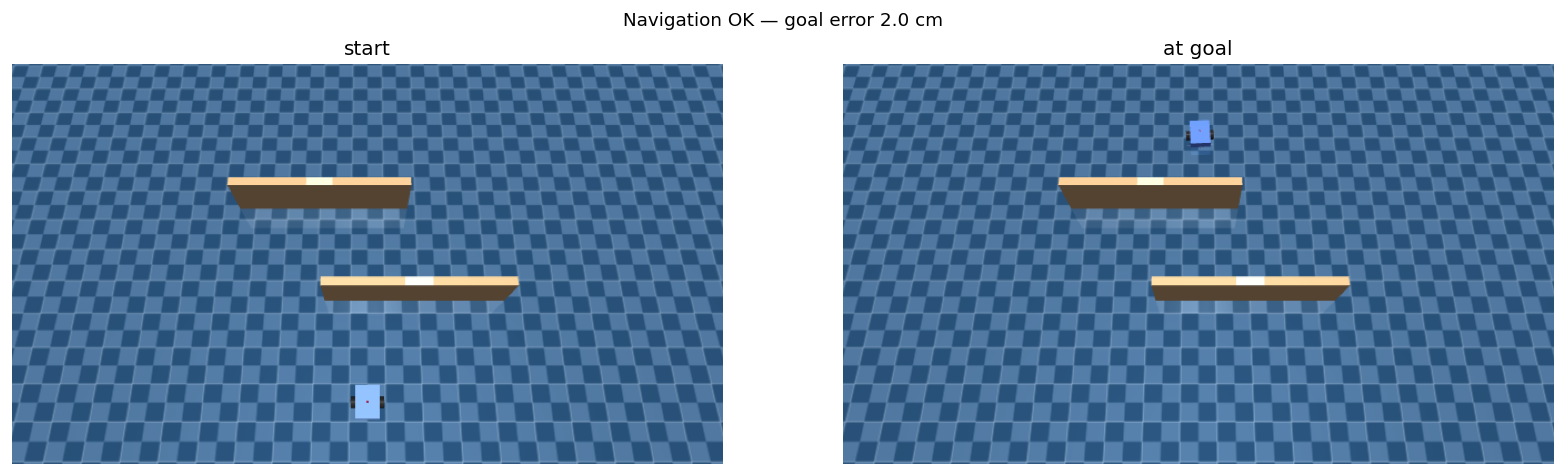

In [25]:
ctrl = DifferentialDriveController(env.get_model(), env.get_data())

if path is not None:
    reset_robot(env)
    before_img = render_view(env, azimuth=0, elevation=-70)

    print("Executing path (headless)...")
    ok = ctrl.follow_waypoints(
        path,
        env,
        final_theta=0.0,   # face +x at goal
        linear_speed=0.4,  # m/s
        angular_speed=1.2, # rad/s
        position_tol=0.12, # m
    )

    x, y, theta = env.get_pose()
    gx, gy = GOAL
    dist_err = np.hypot(x - gx, y - gy)
    print(f"Navigation {'succeeded' if ok else 'FAILED'}")
    print(f"Final pose : x={x:.3f} m, y={y:.3f} m, θ={np.degrees(theta):.1f}°")
    print(f"Goal error : {dist_err*100:.1f} cm")

    after_img = render_view(env, azimuth=0, elevation=-70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(before_img); axes[0].set_title("start");   axes[0].axis("off")
    axes[1].imshow(after_img);  axes[1].set_title("at goal"); axes[1].axis("off")
    plt.suptitle(f"Navigation {'OK' if ok else 'FAILED'} — goal error {dist_err*100:.1f} cm", fontsize=11)
    plt.tight_layout()
    show_fig(fig)

---
## 4. Lidar Sensor

`Lidar` casts rays from a named **site** in the robot model and returns distance measurements. The batched `mj_multiRay` call makes it efficient enough for real-time use.

- **2D mode** (`num_layers=1`): single horizontal ring — ideal for obstacle detection
- **3D mode** (`num_layers>1`): multi-layer sweep with configurable vertical FOV

The robot's lidar is mounted at `lidar_site` on the base link. We scan from the goal position so the nearby walls are visible in the reading.

Lidar scan at goal pose: 360 rays
  min  : 0.945 m
  mean : 4.734 m
  max  : 6.000 m


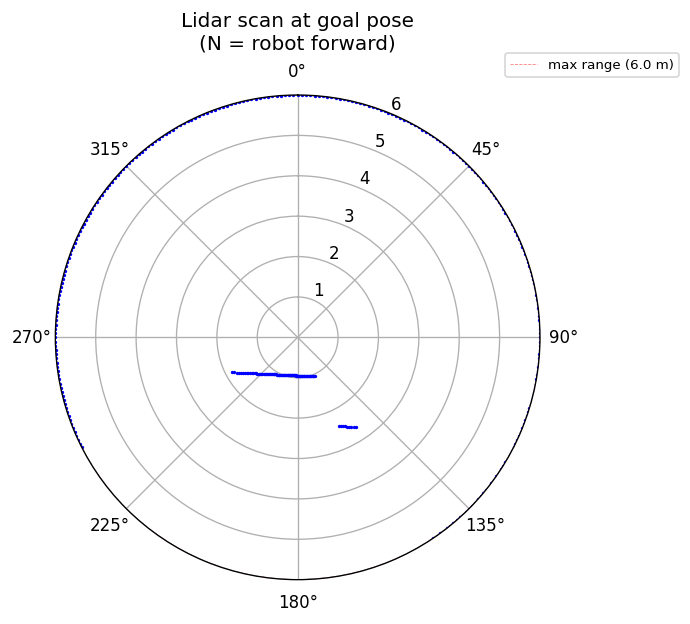

In [26]:
lidar = Lidar(
    env,
    site="lidar_site",
    num_rays=360,
    fov_h=360.0,
    range_max=6.0,
    body_exclude="base_link",
)

distances = lidar.scan()   # shape: (360,)

print(f"Lidar scan at goal pose: {len(distances)} rays")
print(f"  min  : {distances.min():.3f} m")
print(f"  mean : {distances.mean():.3f} m")
print(f"  max  : {distances.max():.3f} m")

# Lidar rays are generated CCW (standard math: angle=0 → +x forward, +π/2 → +y left).
# The polar plot uses a CW compass convention (N=forward, E=right, W=left).
# Negating the angles maps CCW lidar data into the CW compass frame correctly.
angles = np.linspace(0, 2 * np.pi, len(distances), endpoint=False)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
ax.plot(-angles, distances, 'b.', ms=2)
ax.plot(-angles, np.full_like(distances, lidar.range_max),
        'r--', lw=0.5, alpha=0.5, label=f'max range ({lidar.range_max} m)')
ax.set_rmax(lidar.range_max)
ax.set_title("Lidar scan at goal pose\n(N = robot forward)", va='bottom')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
show_fig(fig)

### Geom IDs

Pass `return_geom_ids=True` to identify which object each ray hit:

In [27]:
result   = lidar.scan(return_geom_ids=True)
geom_ids = result["geom_ids"]   # -1 = no hit (max range)

hit_mask = geom_ids >= 0
print(f"Rays that hit something: {hit_mask.sum()} / {len(geom_ids)}")

for gid in np.unique(geom_ids[hit_mask]):
    name = env.model.geom(int(gid)).name
    count = (geom_ids == gid).sum()
    print(f"  geom {gid:3d}  {name!r:30s}  ({count} rays)")

Rays that hit something: 250 / 360
  geom   0  'floor'                         (154 rays)
  geom   6  'wall_a0_geom'                  (9 rays)
  geom   8  'wall_b0_geom'                  (65 rays)
  geom   9  'wall_b1_geom'                  (22 rays)


---
## 5. IMU Sensor

`RobotSensors` wraps the MuJoCo sensor arrays for the IMU mounted on the robot body:
- `imu_acceleration()` — 3-axis accelerometer reading `[ax, ay, az]` in m/s²
- `imu_angular_vel()` — 3-axis gyroscope reading `[wx, wy, wz]` in rad/s

Static readings alone are not very informative. Instead we reset the robot and spin it in place by directly commanding the wheels (`ctrl[0]` = left, `ctrl[1]` = right, both in rad/s). We record the gyroscope Z and accelerometer X over time and plot the resulting time series.

Pose after spin: x=0.000, y=-0.000, θ=67.9°


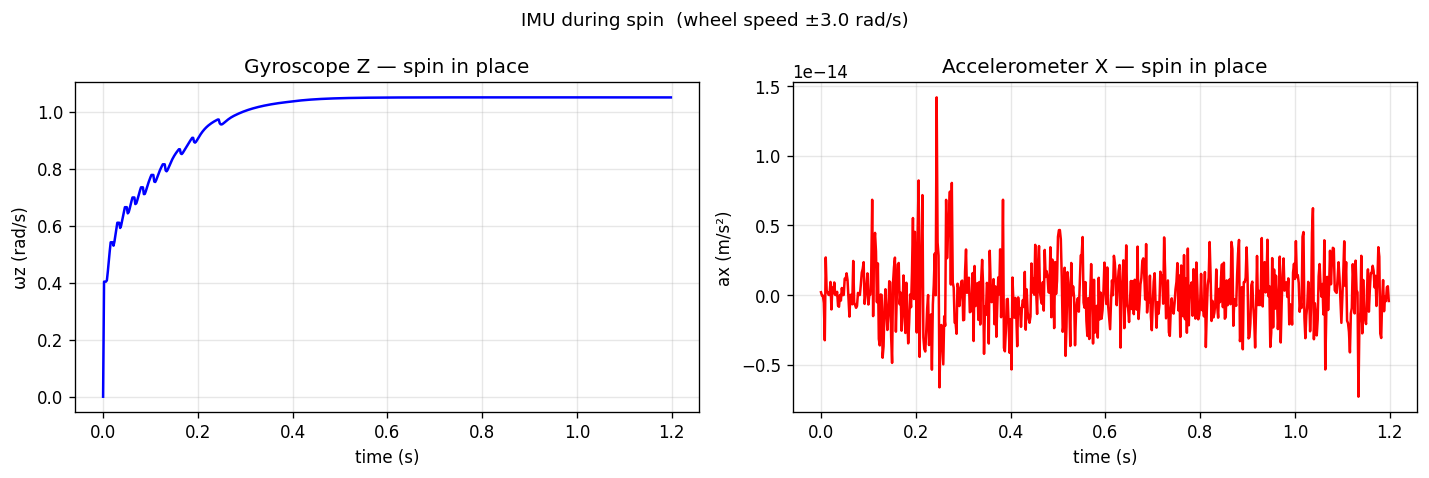

In [28]:
sensors = RobotSensors(env, imu_accel_name="imu_accel", imu_gyro_name="imu_gyro")

reset_robot(env)

# Spin in place: left wheel backward, right wheel forward
SPIN_STEPS  = 600
WHEEL_SPEED = 3.0   # rad/s
dt = env.model.opt.timestep

env.data.ctrl[0] = -WHEEL_SPEED
env.data.ctrl[1] =  WHEEL_SPEED

times   = []
gyro_z  = []
accel_x = []

for i in range(SPIN_STEPS):
    env.step()
    g = sensors.imu_angular_vel()
    a = sensors.imu_acceleration()
    times.append(i * dt)
    gyro_z.append(g[2]  if g is not None else 0.0)
    accel_x.append(a[0] if a is not None else 0.0)

env.data.ctrl[:] = 0.0

x, y, theta = env.get_pose()
print(f"Pose after spin: x={x:.3f}, y={y:.3f}, θ={np.degrees(theta):.1f}°")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(times, gyro_z, 'b-', lw=1.5)
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('ωz (rad/s)')
axes[0].set_title('Gyroscope Z — spin in place'); axes[0].grid(True, alpha=0.3)
axes[1].plot(times, accel_x, 'r-', lw=1.5)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('ax (m/s²)')
axes[1].set_title('Accelerometer X — spin in place'); axes[1].grid(True, alpha=0.3)
plt.suptitle(f"IMU during spin  (wheel speed ±{WHEEL_SPEED} rad/s)", fontsize=11)
plt.tight_layout()
show_fig(fig)

---
## 6. Odometry Drift

A useful sanity check is to drive a closed shape and measure the accumulated pose error. Here we build a fresh obstacle-free scene, drive a 1 m square, and compare the robot's final pose against the origin. The before/after renders show any visible displacement.

Driving a 1.0 m square...
Final pose : x=+0.0101 m, y=+0.0018 m, θ=-2.85°
Drift      : 1.03 cm from origin


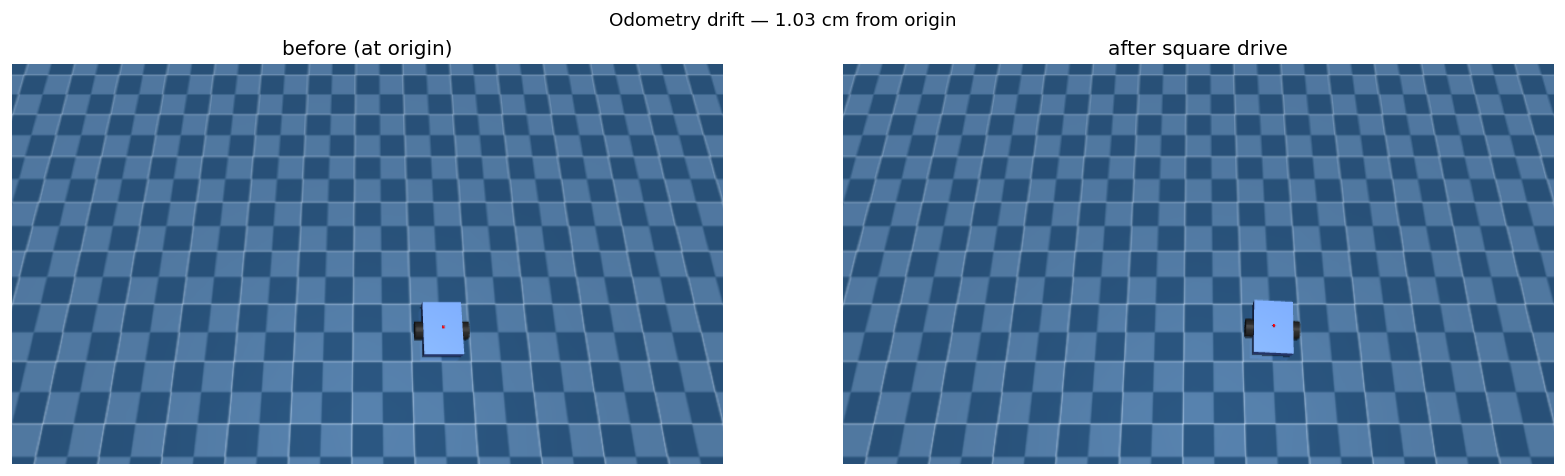

In [29]:
drift_env  = MobileSceneBuilder().build_env(env_class=MobileEnvironment, rate=1_000_000)
drift_ctrl = DifferentialDriveController(drift_env.get_model(), drift_env.get_data())

reset_robot(drift_env)
before_img = render_view(drift_env, lookat=(0.5, 0.5, 0.0), distance=3.5, azimuth=0, elevation=-70)

SIDE    = 1.0
corners = [(SIDE, 0.0), (SIDE, SIDE), (0.0, SIDE), (0.0, 0.0)]

print(f"Driving a {SIDE} m square...")
drift_ctrl.follow_waypoints(
    corners, drift_env,
    final_theta=0.0,
    linear_speed=0.4,
    angular_speed=1.2,
    position_tol=0.08,
)

x, y, theta = drift_env.get_pose()
dist_err = np.hypot(x, y)
print(f"Final pose : x={x:+.4f} m, y={y:+.4f} m, θ={np.degrees(theta):.2f}°")
print(f"Drift      : {dist_err*100:.2f} cm from origin")

after_img = render_view(drift_env, lookat=(0.5, 0.5, 0.0), distance=3.5, azimuth=0, elevation=-70)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(before_img); axes[0].set_title("before (at origin)"); axes[0].axis("off")
axes[1].imshow(after_img);  axes[1].set_title("after square drive"); axes[1].axis("off")
plt.suptitle(f"Odometry drift — {dist_err*100:.2f} cm from origin", fontsize=11)
plt.tight_layout()
show_fig(fig)

---
## Next Steps

| What you want | Where to look |
|---------------|---------------|
| Live navigation in viewer | `python examples/basic_navigation.py` |
| Multi-lap drift measurement | `python examples/square_drive.py` |
| 3D Lidar (multi-layer) | `Lidar(..., num_layers=32, fov_v=30.0)` |
| Franka arm | `notebooks/franka_getting_started.ipynb` |
| YCB objects in mobile scenes | `tampanda.scenes.YCBDownloader` |